<center><a target="_blank" href="https://academy.constructor.org/"><img src=https://lh3.googleusercontent.com/d/1fypIr9T-7ntcsVQFmC2_iMPcsm7h8jXg width="500" style="background:none; border:none; box-shadow:none;" /></a> </center>
<hr />

# <h1 align="center"> Exercises: Design & Storytelling </h1>

<p style="margin-bottom:1cm;"></p>

_____

<center>Constructor Nexademy, 2026</center>

# Exercises: Design & Storytelling


The exercises for Day 2 are practice techniques for telling stories with data.

## Table of contents

*  Exercise 1: Layering
*  Exercise 2: More Layering
*  Exercise 3: Faceting
*  Exercise 4: Anscombe's Quartet
*  Exercise 5: Even More Layering
*  Exercise 6: Presentation


## Preamble

In [2]:
# import packages
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# use seaborn style
sns.set()
sns.set_style('darkgrid')

## Read in data

**SNB Money-market Rate Data**

Data on the money-market rates over various terms, including: overnight (`SARON`), call money rate (`1TGT`), 1, 3, 6, and 12-month CHF-denominated loans (`1M`, `3M0`, `6M`, `12M`, respectively), and USD, JPY, GBP, and EUR-denominated loans (`3M1`, `3M2`, `3M3`, and `3M4`, respectively)

Used in Ex 1

In [4]:
snb_df = pd.read_csv("/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day2/data/snb-data-zimoma-en-all-20200901_1437.csv", sep=";", skiprows=2)
snb_df = snb_df.rename({'D0': 'Instrument'}, axis=1)
snb_df['Date'] = pd.to_datetime(snb_df['Date'])
snb_df = snb_df.set_index(['Date', 'Instrument']).unstack()['Value']
term_order = ['SARON', '1TGT', '1M', 'EG3M', '3M0', '3M1', '3M2', '3M3', '3M4', '6M', '12M']
snb_df = snb_df[term_order]
snb_df.head()

Instrument,SARON,1TGT,1M,EG3M,3M0,3M1,3M2,3M3,3M4,6M,12M
Date,,,,,,,,,,,
1972-01-01,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-02-01,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-03-01,NaN,0.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-04-01,NaN,0.250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972-05-01,NaN,1.500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**MPG Data**

Data about a selection of automobiles in two years: 1999 and 2008. Includes information about the manufacturer and model of each car, as well as data on the type of car (`class`), the size of the engine (`displ`, `cyl`), the type of transmission (`trans`), and city and highway fuel efficiency (`cty`, `hwy`) in miles/gallon of fuel units.

Used in Ex 2, 3

In [5]:
mpg_df = pd.read_csv("/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day2/data/mpg.csv")
mpg_df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


**Anscombe's Quartet**

Synthetic data with some strange properties, made up of four data sets. Contains three columns, `dataset`, to identify which dataset each row belongs to, and `x`, and `y` values.

Used in Ex 4

In [6]:
anscombe_df = pd.read_csv('/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day2/data/anscombe.csv')
anscombe_df.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


**Mortality Data**

Data on the daily number of deaths in France from 1 Jan, 2000 to 18 May, 2020. The columns `month` and `day` are the month and day of the data, the columns 2000-2020 are the data for those years.

Used in Ex 5

In [7]:
mort_df = pd.read_csv('/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day2/data/morts_2020-05-18.csv')
month_day_df = mort_df['mois_jour'].str.split("/", expand=True)
month_day_df.columns = ['month', 'day']
month_day_df = month_day_df.astype('int32')
mort_df = month_day_df.join(mort_df)
# Get rid of Feb 29, we can ignore it
mort_df = mort_df.dropna(axis=0, subset=['2001'])
mort_df.head()

,month,day,mois_jour,2000,2001,2002,2003,2004,2005,2006,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,1,1,01/01,1974,1670.0,1886.0,1640.0,1798,1757.0,1699.0,...,1819.0,1813,1874.0,1701.0,1877.0,1761,2204.0,2027.0,1839,1895.0
1,1,2,01/02,2040,1777.0,1927.0,1801.0,1829,1537.0,1765.0,...,1810.0,1754,1872.0,1780.0,1972.0,1797,2371.0,2142.0,1935,1892.0
2,1,3,01/03,2086,1775.0,1850.0,1701.0,1807,1672.0,1813.0,...,1881.0,1743,1866.0,1712.0,1958.0,1726,2352.0,2137.0,1880,1940.0
3,1,4,01/04,2080,1701.0,1887.0,1605.0,1701,1679.0,1720.0,...,1814.0,1762,1803.0,1693.0,1856.0,1835,2251.0,2160.0,1900,1821.0
4,1,5,01/05,2039,1697.0,1792.0,1569.0,1901,1665.0,1661.0,...,1875.0,1757,1748.0,1618.0,1978.0,1778,2272.0,2099.0,1921,1734.0


## Ex. 1: Layering

Layering can be used to provide context necessary for interpreting data. We are going to take the line chart from yesterday and layer context onto the chart.

### Ex. 1.1

The snb_df includes a `1TGT` column for of rates for tomorrow-next loans. Plot a line chart of this column, and layer the following events and data on top of the chart.

* 1973-11: Oil Price Shock
* 1991-01 – 1993-12: Recession in Switzerland
* 2009-01 – 2009-12: Recession in Switzerland
* 2008-09: Lehman-Brothers collapse
* 2011-08: Introduction of CHF/EUR floor
* 2015-01: Removal of CHF/EUR floor

(Matplotlib documentation for [annotations](http://matplotlib.org/users/annotations.html) and [axvspan](https://matplotlib.org/api/_as_gen/matplotlib.axes.Axes.axvspan.html) will be helpful here.)


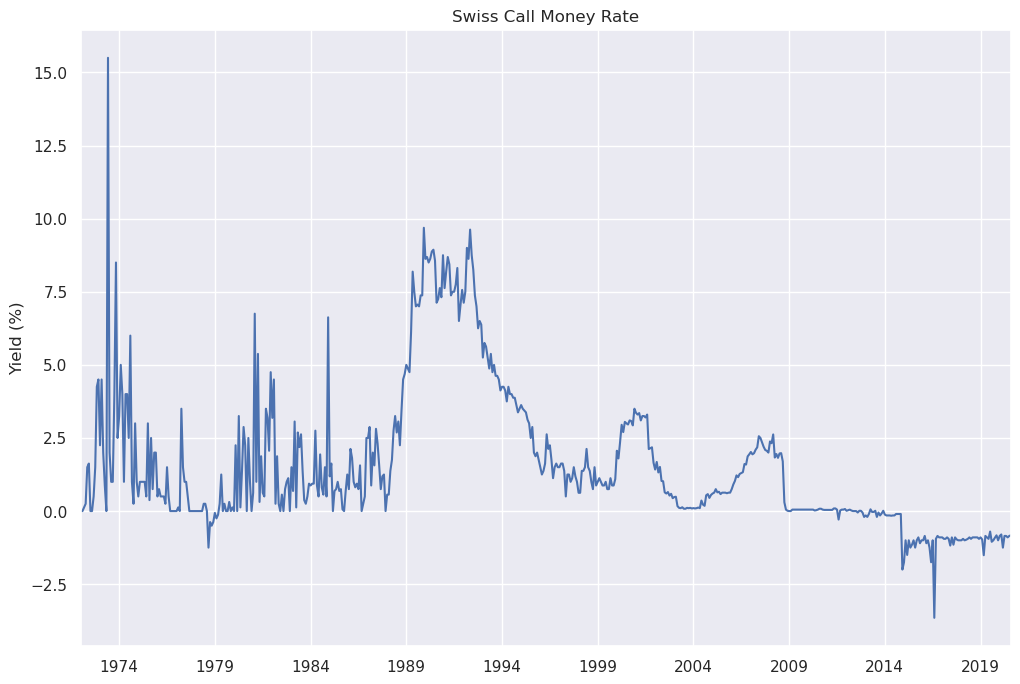

In [8]:
# Here is the initial plot to get you started
# Add the events to this plot
fig, ax = plt.subplots(figsize=(12, 8))
ser = snb_df['1TGT']
ser.plot(ax=ax)
ax.set_title("Swiss Call Money Rate")
ax.set_xlabel("")
ax.set_ylabel("Yield (%)");

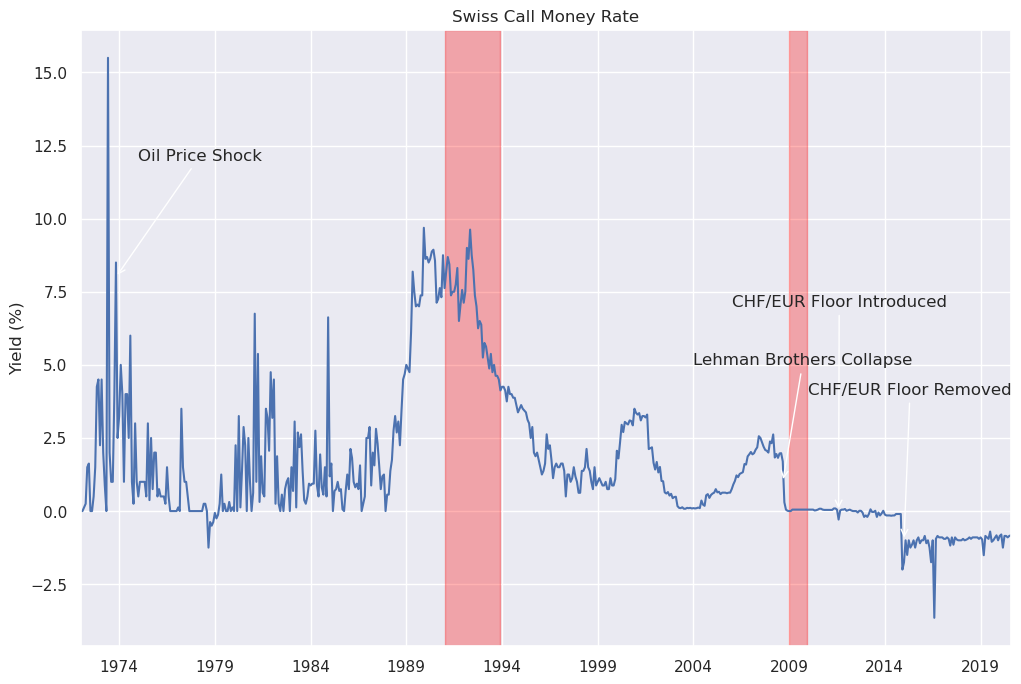

In [28]:
# code your solution here

fig, ax = plt.subplots(figsize=(12, 8))

# Main line
ser = snb_df['1TGT']
ser.plot(ax=ax)

# Recession periods
ax.axvspan('1991-01', '1993-12', color='red', alpha=0.3)
ax.axvspan('2009-01', '2009-12', color='red', alpha=0.3)

# Important events
ax.annotate(
    'Oil Price Shock',
    xy=('1973-11', 8),
    xytext=('1975-01', 12),
    arrowprops=dict(arrowstyle='->')
)

ax.annotate(
    'Lehman Brothers Collapse',
    xy=('2008-09', 1),
    xytext=('2004-01', 5),
    arrowprops=dict(arrowstyle='->')
)

ax.annotate(
    'CHF/EUR Floor Introduced',
    xy=('2011-08', 0),
    xytext=('2006-01', 7),
    arrowprops=dict(arrowstyle='->')
)

ax.annotate(
    'CHF/EUR Floor Removed',
    xy=('2015-01', -1),
    xytext=('2010-01', 4),
    arrowprops=dict(arrowstyle='->')
)

# Labels
ax.set_title("Swiss Call Money Rate")
ax.set_xlabel("")
ax.set_ylabel("Yield (%)")

plt.show()

### Ex 1.2

Save the plot made in 1.1 as a PDF file.

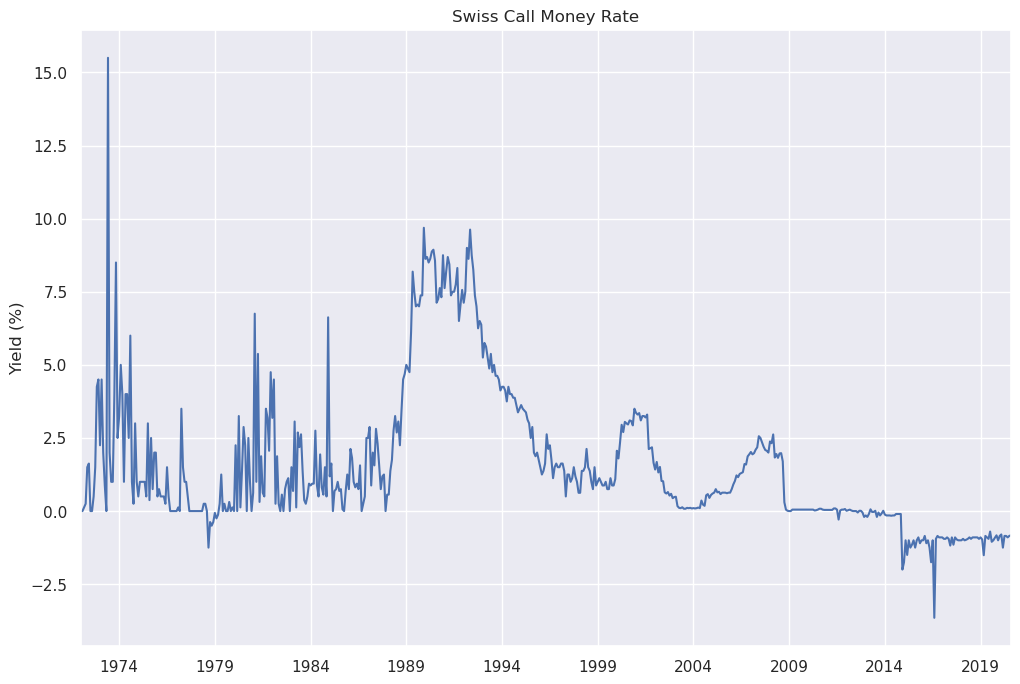

In [10]:
# code your solution here
fig, ax = plt.subplots(figsize=(12, 8))
ser = snb_df['1TGT']
ser.plot(ax=ax)
ax.set_title("Swiss Call Money Rate")
ax.set_xlabel("")
ax.set_ylabel("Yield (%)");
plt.savefig("chart1.1.pdf")
plt.show()

### Ex 2: More Layering

### Ex 2.1

For this exercise, we will use the `mpg_df` dataframe. We will start with a scatterplot with `displ` on the x-axis and `hwy` on the y-axis.

For the car or cars with the best and worst highway fuel milage, plot the data points observing:
- Use [Brewer Set1](https://colorbrewer2.org/#type=qualitative&scheme=Set1&n=7) green for the best (#4DAF4A) and the red for the worst (#E41A1C)
- Make the dot size larger (10 points, s = 100)
- Label the point with manufacturer(s) of automobile (column `manufacturer` in the dataframe)


In [11]:
# code your solution here

max_hwy = mpg_df['hwy'].max()
min_hwy = mpg_df['hwy'].min()

best_cars = mpg_df[mpg_df['hwy'] == max_hwy]
worst_cars = mpg_df[mpg_df['hwy'] == min_hwy]

print("\n best cars:\n" ,best_cars[['manufacturer', 'hwy']])
print("\n worst cars:\n" , worst_cars[['manufacturer', 'hwy']])



 best cars:
     manufacturer  hwy
212   volkswagen   44
221   volkswagen   44

 worst cars:
     manufacturer  hwy
54         dodge   12
59         dodge   12
65         dodge   12
69         dodge   12
126         jeep   12


soton bala masan behtarin ba 44 galon sokht rh mire toie highway
badatrin 12 rah mire


Step 1, identify the cars with the best and worst fuel mileage, and their manufacturers

In [12]:
# try to solve this yourself. If you are stuck, uncomment the next line and execute this cell
#%load fragment-2.1.1.py

Step 2, plot the full plot together with the best/worst cars and labels for the manufacturers

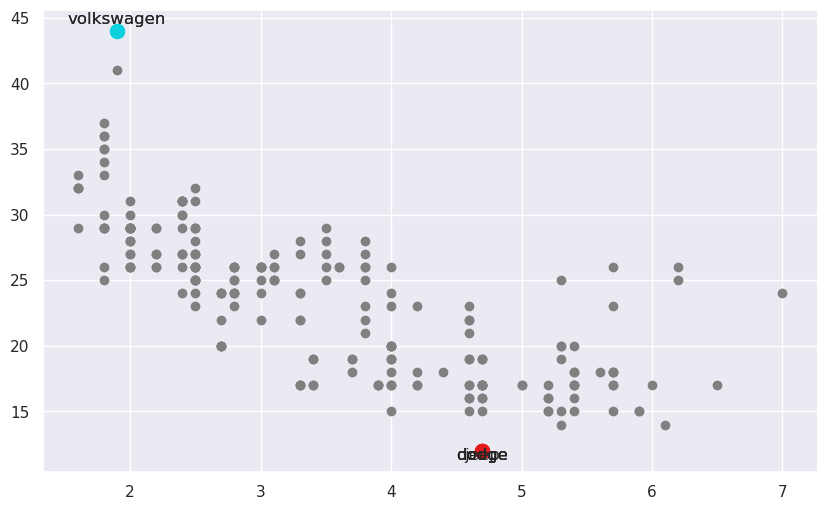

In [13]:
# code your solution here


fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(mpg_df['displ'], mpg_df['hwy'], color='gray')

ax.scatter(best_cars['displ'], best_cars['hwy'], color="#0BD1DF", s=100)
for index, row in best_cars.iterrows():
    ax.text(row['displ'], row['hwy'] + 0.5, row['manufacturer'], ha='center')

ax.scatter(worst_cars['displ'], worst_cars['hwy'], color='#E41A1C', s=100)
for index, row in worst_cars.iterrows():
    ax.text(row['displ'], row['hwy'] - 0.7, row['manufacturer'], ha='center')

plt.show()


### Ex 2.2

Starting with the plot from 2.1, draw a linear model of the relationship between displacement and highway mileage in Brewer Set1 orange (#ff7f00) over the plot. Label the line with the $r^2$ of the model.

Step 1, build a linear model of `hwy` as a function of `displ`

In [14]:
import statsmodels.formula.api as smf

def fit_and_predict(df):

    # find conection between highway benzin o engine size 
    lm = smf.ols(formula="hwy ~ displ", data=df).fit()
    
    #inja saro tah nemodar o khatemon moshahase kamtarin o bihtarin hajme motor
    x_bounds = [df['displ'].min(), df['displ'].max()]

    #injam min o max ro dataframe o jadwal mikonim 
    preds_input = pd.DataFrame({'displ': x_bounds})

    #pishbini ya predict miknoim ke max o mon hajm o masraf benzin bayad chi base
    predictions = lm.predict(preds_input)

    # inja model ye dataframe mide ke on line ke donbaleshim ro dare min o max
    return lm, pd.DataFrame({'displ': x_bounds, 'hwy': predictions})


lm, pred = fit_and_predict(mpg_df)
# r^2  baraie deghato accurec pishnini min o max
rsquared = lm.rsquared


Step 2, draw the plot and add a line of the model

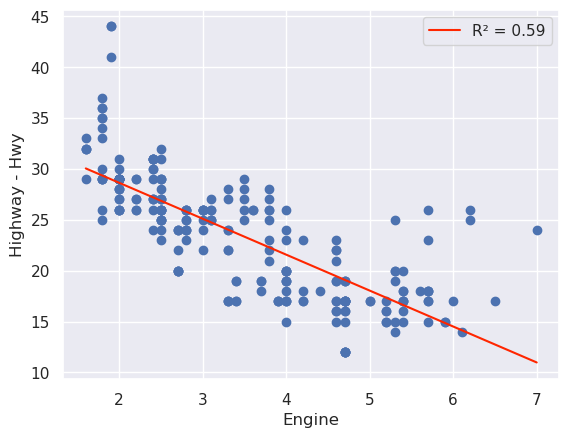

In [15]:
plt.scatter(mpg_df['displ'], mpg_df['hwy'])

plt.plot(pred['displ'], pred['hwy'], color="#ff2600", label=f'R² = {rsquared:.2f}')

plt.xlabel('Engine')
plt.ylabel('Highway - Hwy')


# in label ro mikhone o label chap mikone hamejaie code
plt.legend()

plt.show()

## Ex. 3: Faceting

Faceting can be used to show more data, provide context, and make a visualization easier to undersatand.

### Ex 3.1

Using the mpg_df dataframe, scatterplot `displ` on the x-axis and `hwy` on the y-axis, facet by class of car (the `class` column). Give the figure the title (`suptitle`), `Engine Size vs. Highway Fuel Mileage`, and label the y-axis `MPG` and x-axis `Displacement (Liters)`.

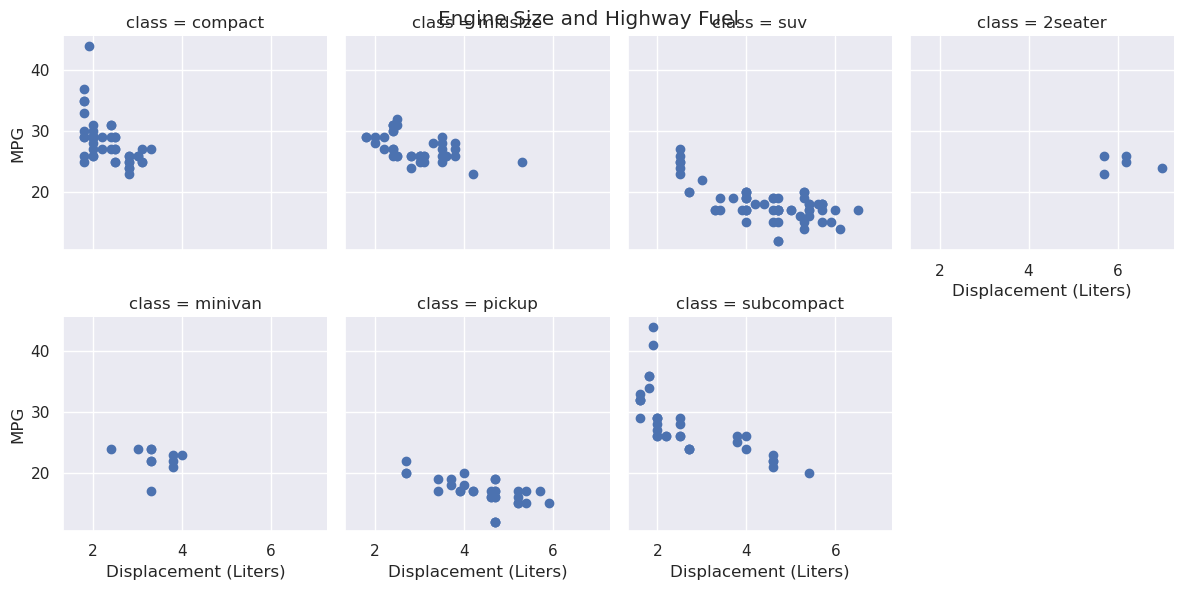

In [16]:
# code your solution here


g = sns.FacetGrid(mpg_df, col='class',col_wrap=4) #tedade har jadwal dar ye radife

g.map(plt.scatter, 'displ', 'hwy')

g.set_axis_labels('Displacement (Liters)', 'MPG')

g.figure.suptitle('Engine Size and Highway Fuel ')

plt.show()

### Ex 3.2

Make the same plot as in 3.1, but this time **sort the facets** by the mean displacement for each class.

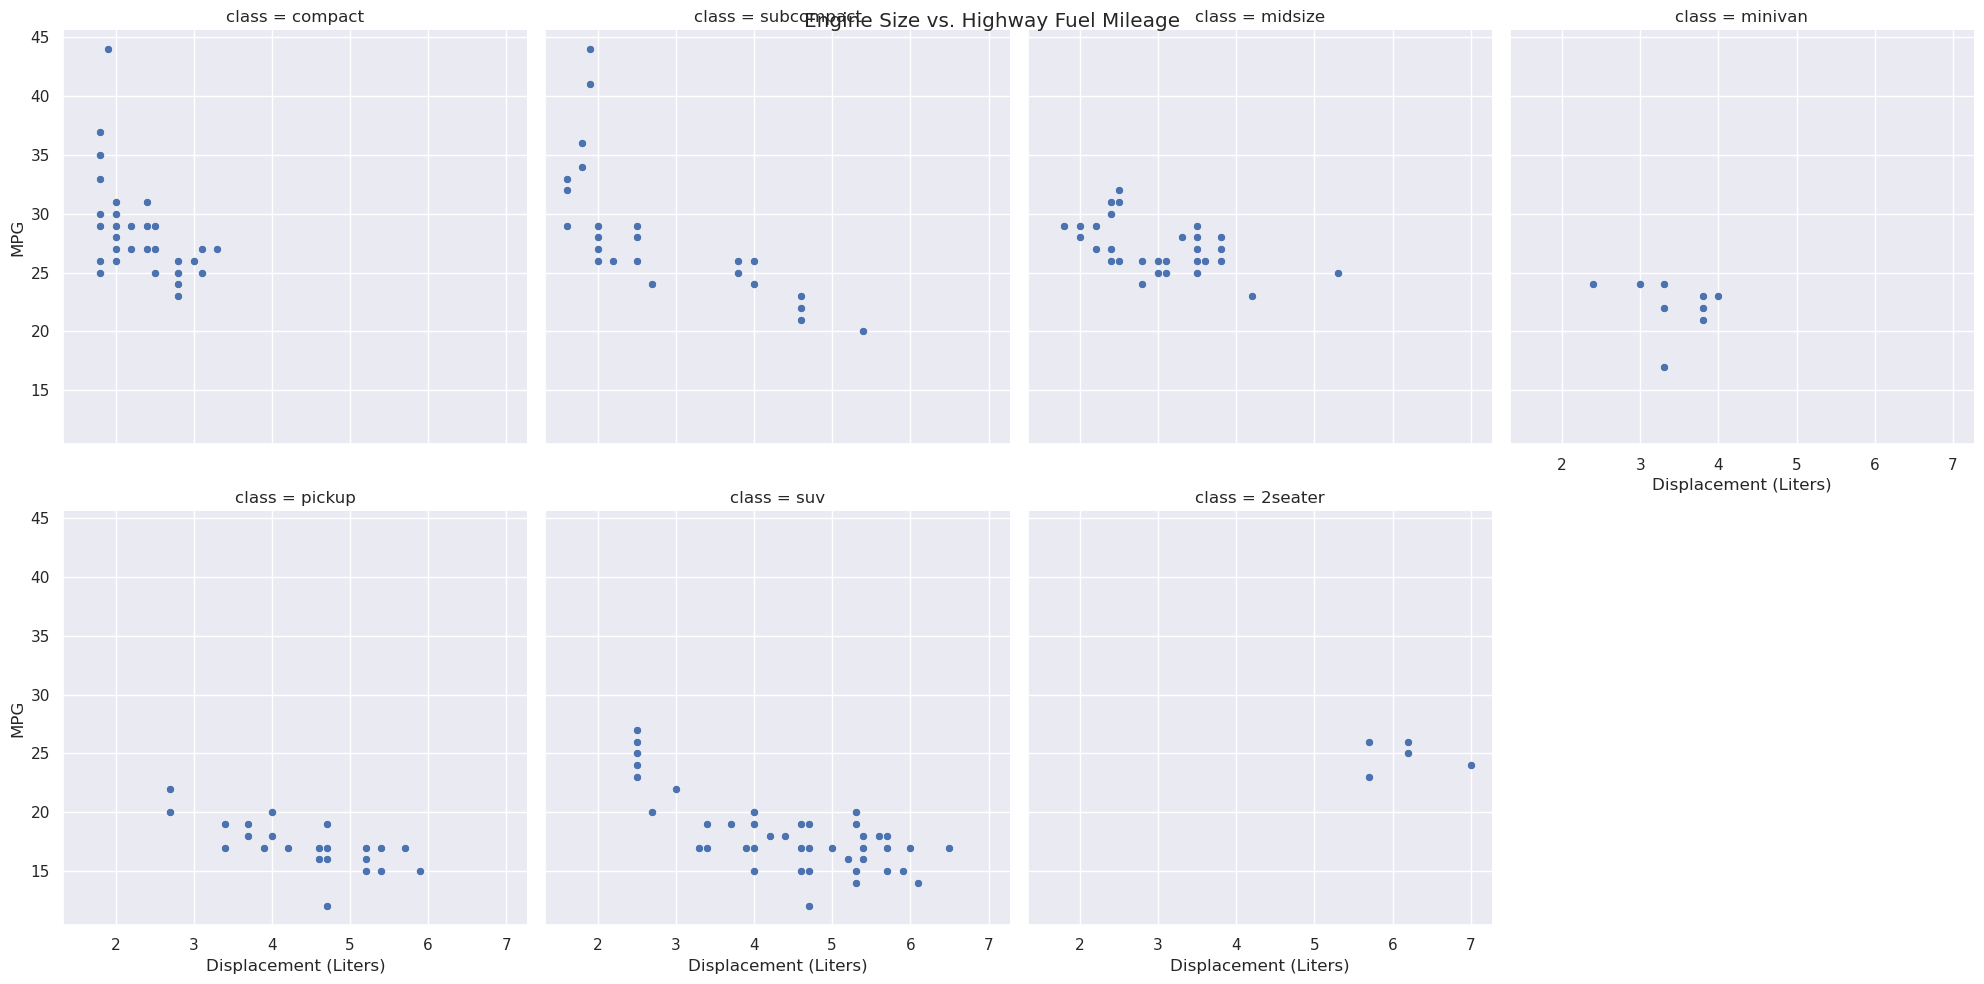

In [17]:
# code your solution here


#gorop by classs ar mashin o avrage hajm motor o az min be max moratab mikonim
class_order = mpg_df.groupby('class')['displ'].mean().sort_values().index


g = sns.relplot(data=mpg_df, x='displ', y='hwy', col='class', col_order=class_order  ,col_wrap=4)

g.figure.suptitle('Engine Size vs. Highway Fuel Mileage')
g.set_axis_labels('Displacement (Liters)', 'MPG')

plt.show()

code bala morstab krde o tahlil o analyz ro ason mikone 

### Ex 3.3

Make the same plot as in 3.2, but this time highlight the car or cars with the best and worst fuel mileage, as was done in 2.1, and draw in the linear model from 2.2. That is:

For the car or cars with the best and worst highway fuel milage, plot the data points observing:
- Use Brewer Set1 blue for the best (#377EB8) and the red for the worst (#E41A1C)
- Label the point with model(s) of automobile (column `model` in the dataframe)

And draw a linear model of the relationship between displacement and highway mileage over the plot (do not add the $r^2$ as text).

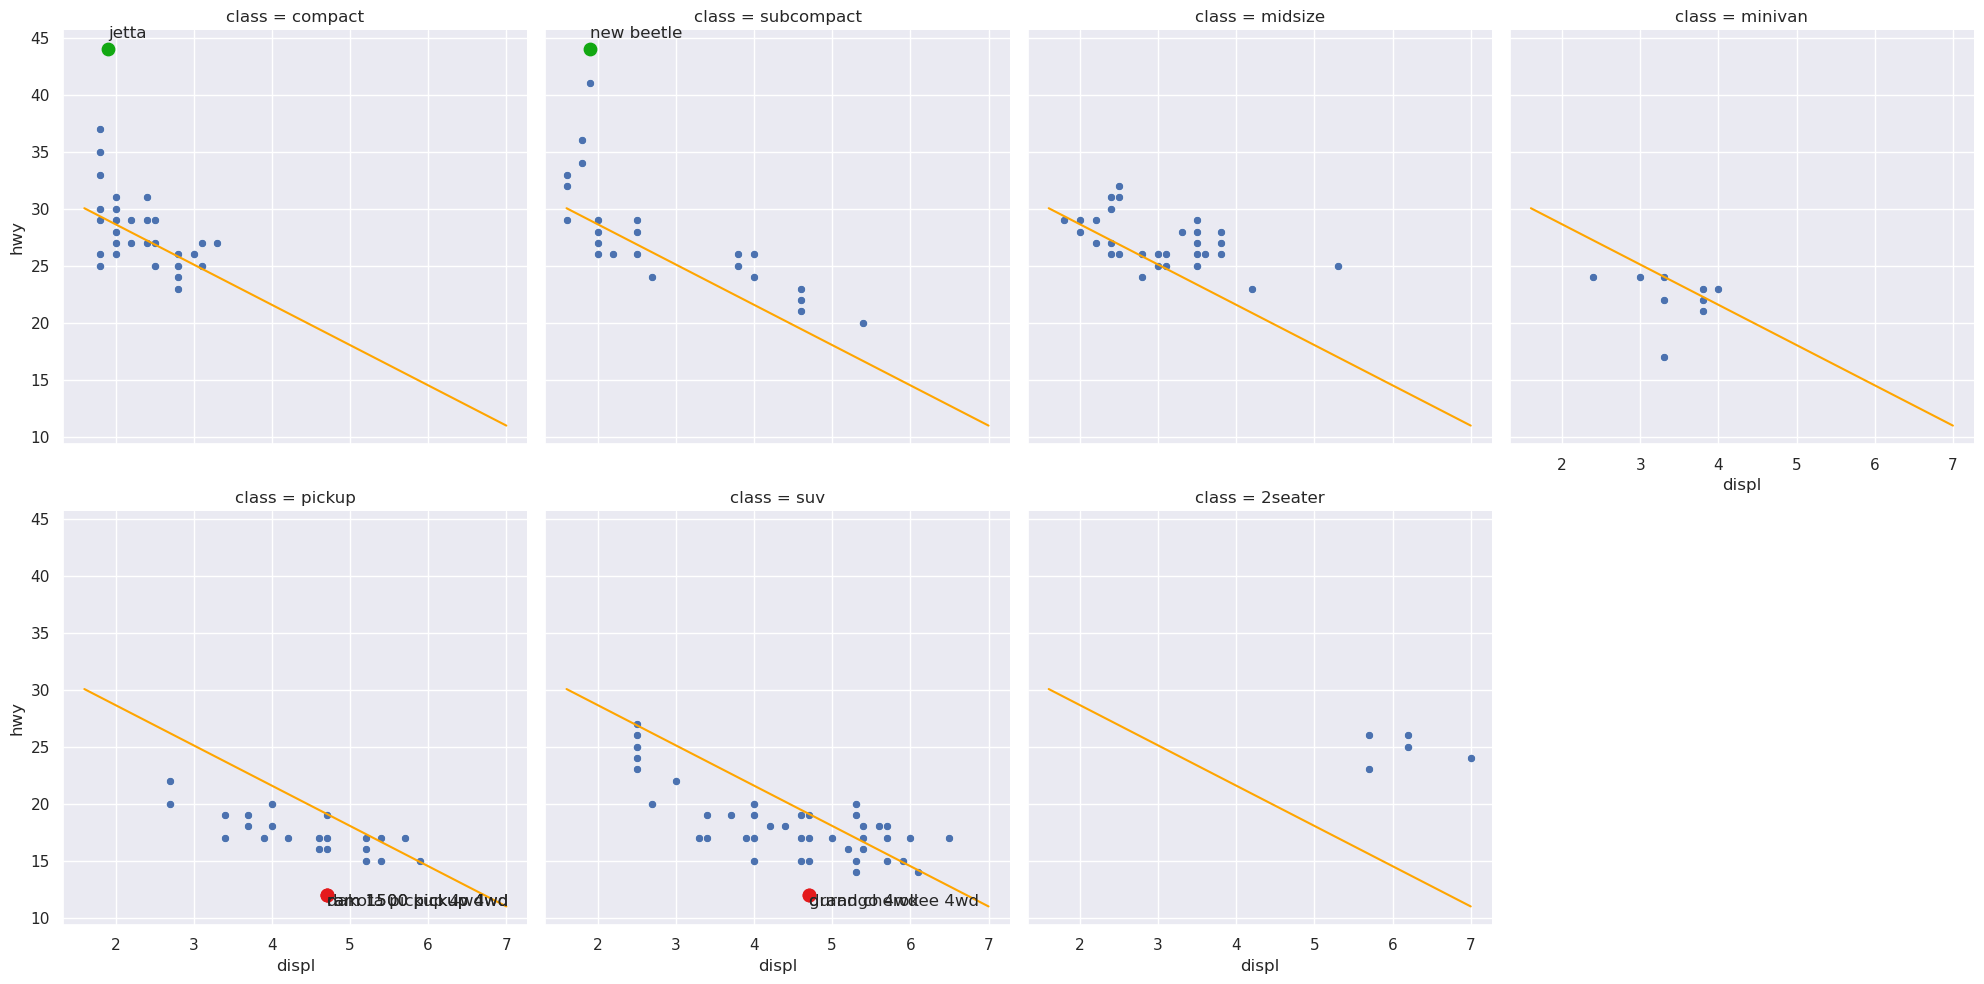

In [18]:
# code your solution here

class_order = mpg_df.groupby('class')['displ'].mean().sort_values().index

g = sns.relplot(
    data=mpg_df,
    x='displ',
    y='hwy',
    col='class',
    col_order=class_order,
    col_wrap=4
)

for class_name, ax in g.axes_dict.items():

    ax.plot(pred['displ'], pred['hwy'] , color='orange')

    best = best_cars[best_cars['class'] == class_name]
    ax.scatter(best['displ'], best['hwy'], color="#12A812", s=80)

    for _, row in best.iterrows():
        ax.text(row['displ'], row['hwy'] + 1, row['model'])

    worst = worst_cars[worst_cars['class'] == class_name]
    ax.scatter(worst['displ'], worst['hwy'], color='#E41A1C', s=80)

    for _, row in worst.iterrows():
        ax.text(row['displ'], row['hwy'] - 1, row['model'])

plt.show()

## Ex 4: Anscombe's Quartet

This exercise works with anscombe_df.

### Ex 4.1

There are 4 data sets in the frame (indicated by the dataset column): what is the mean x, and mean y for each data set?

In [19]:
# code your solution 
import pandas as pd

anscombe_df = pd.read_csv('/home/soraan/Desktop/karzanmahmoudi/03_Visualization/day2/data/anscombe.csv')

anscombe_df.groupby('dataset')[['x', 'y']].mean()


,x,y
dataset,,
I,9.0,7.500909
II,9.0,7.500909
III,9.0,7.500000
IV,9.0,7.500909


### Ex 4.2

Compute a linear regression for each data set. What is the slope and intercept?

Make a faceted plot, one subplot for each dataset, drawing the points at their specified x/y values. Layer the regression lines over the plot. Label the regression lines with slope, intercept, and r^2.

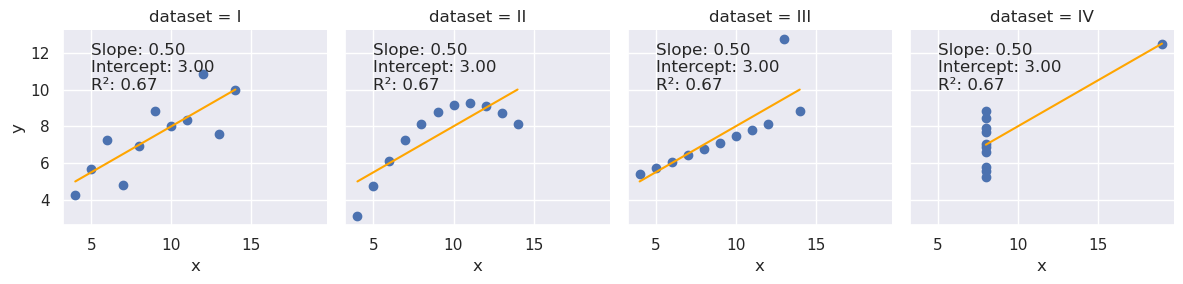

In [20]:

g = sns.FacetGrid(anscombe_df, col='dataset')
g.map(plt.scatter, 'x', 'y')

for name, ax in g.axes_dict.items():
    subset = anscombe_df[anscombe_df['dataset'] == name]
    model = smf.ols(formula="y ~ x", data=subset).fit()
    
    slope = model.params['x']
    intercept = model.params['Intercept']
    r_squared = model.rsquared
    
    x_points = [subset['x'].min(), subset['x'].max()]
    y_points = [slope * x_points[0] + intercept, slope * x_points[1] + intercept]
    ax.plot(x_points, y_points, color='orange')
    
    text = f"Slope: {slope:.2f}\nIntercept: {intercept:.2f}\nR²: {r_squared:.2f}"
    ax.text(5, 10, text)

plt.show()

### Ex. 4.3

*How appropriate is the linear model for each data set?*

A linear model makes sense for data set I, but is questionable for the others. It might make sense for III, but the strange outlier would need to be accounted for. II looks like it would be better modelled with a quadratic function, and something very different is going on in IV.

## Ex 5: Even More Layering

Let us recreate this fantastic graphic using the `mort_df`. For more background, see the following (all in French):
* http://coulmont.com/blog/2020/04/24/2020-une-mortalite-specifique/
* https://freakonometrics.hypotheses.org/60845
* https://www.lemonde.fr/les-decodeurs/article/2020/04/27/coronavirus-un-pic-tres-net-de-mortalite-en-france-depuis-le-1er-mars-par-rapport-aux-vingt-dernieres-annees_6037912_4355770.html

![COVID-19 in FR](http://coulmont.com/vordpress/wp-content/uploads/2020/04/deces-2001-2020-blog-general.png)

* Plot the day number in year (going from 0 to 364 or 365) on the x-axis, and the number of deaths for that each year on the y-axis.

Step 1, find the boundries for the month in the data

In [21]:

import datetime
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_cutoff = np.array([0] + days_in_month).cumsum()[:-1]
month_names = [datetime.date(2020, i+1, 1).strftime("%h") for i in range(len(days_in_month))]

Step 2, plot one year of data to see what it looks like

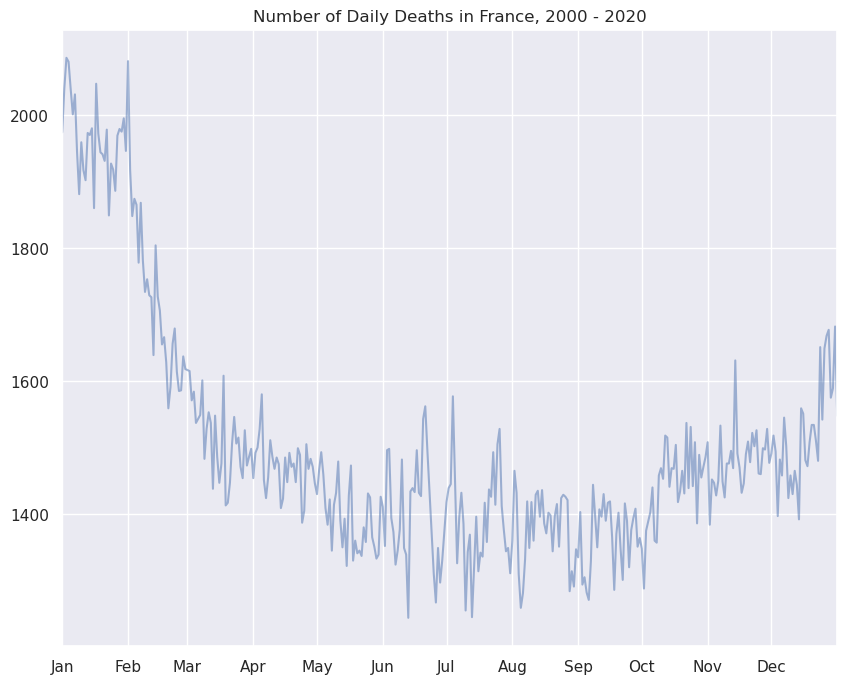

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(mort_df.index, mort_df['2000'], alpha=0.5)
ax.set_xlim([0, 365])
ax.set_xticks(month_cutoff)
ax.set_title("Number of Daily Deaths in France, 2000 - 2020")
ax.set_xticklabels(month_names);

Step 3, plot the remaining years of data, up to 2019

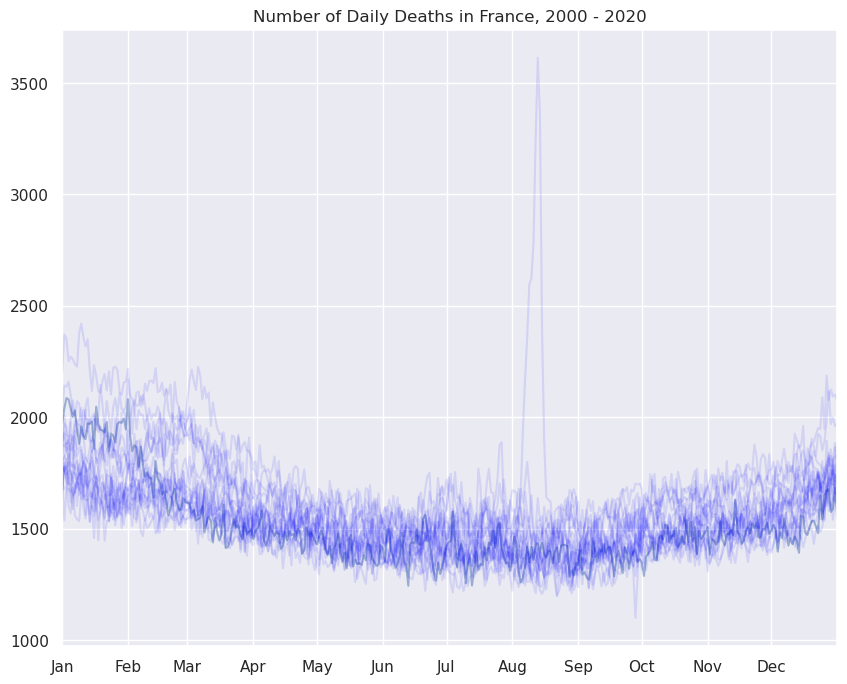

In [23]:
for year in range(2001, 2020):
    year_text = str(year)
    ax.plot(mort_df.index, mort_df[year_text], color="blue", alpha=0.1)

fig

Step 4, plot the 2020 data in red and label it as the `Year 2020`

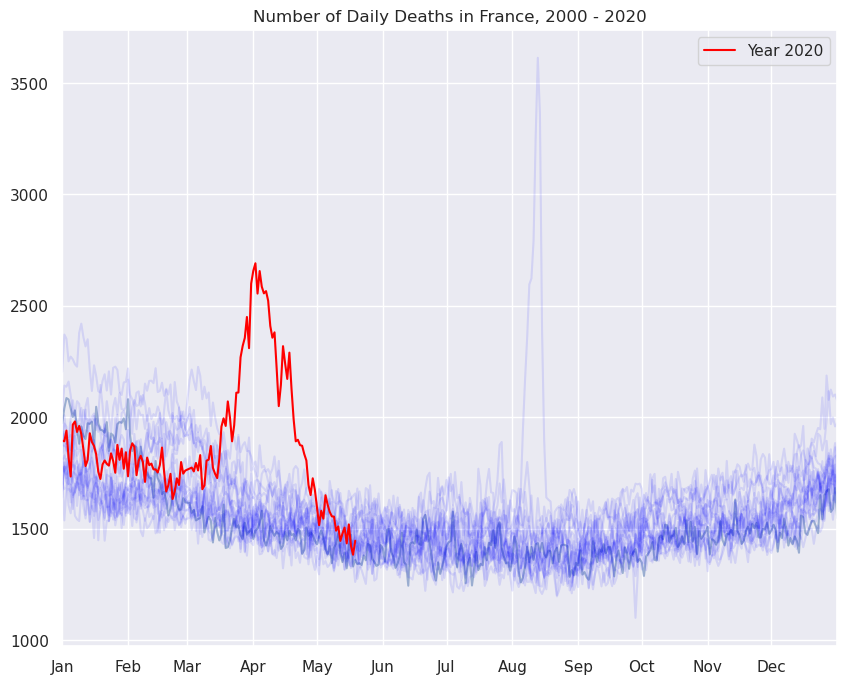

In [24]:
# code your solution here


ax.plot(mort_df.index, mort_df["2020"], color="red", label="Year 2020")

ax.legend()
fig

Step 5
* label the big spike that goes over 3000 as `Heatwave, 2003`
* compute the average number of deaths per day, and layer a line with the average
* label the average line `Mean deaths, 2000-2019`

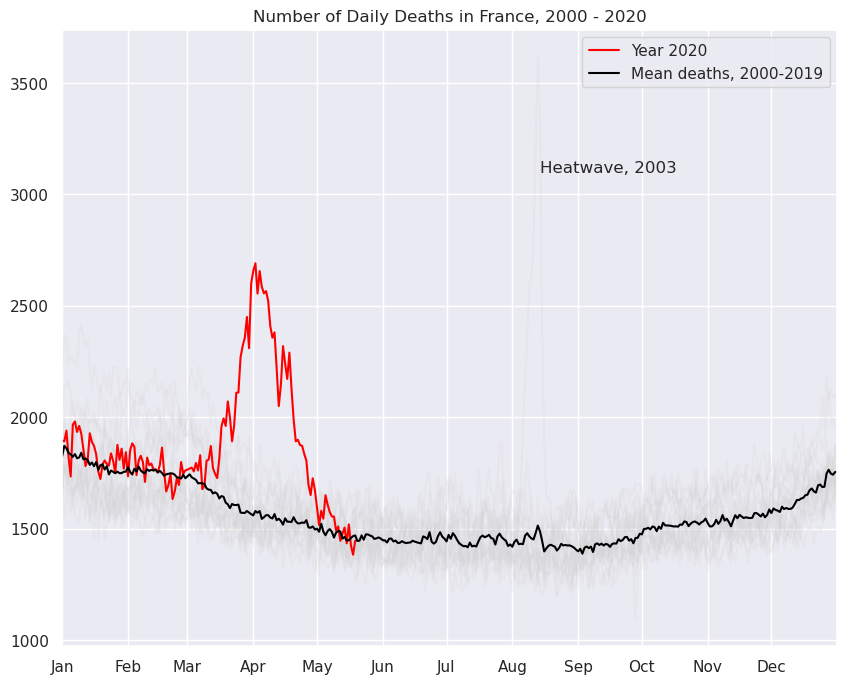

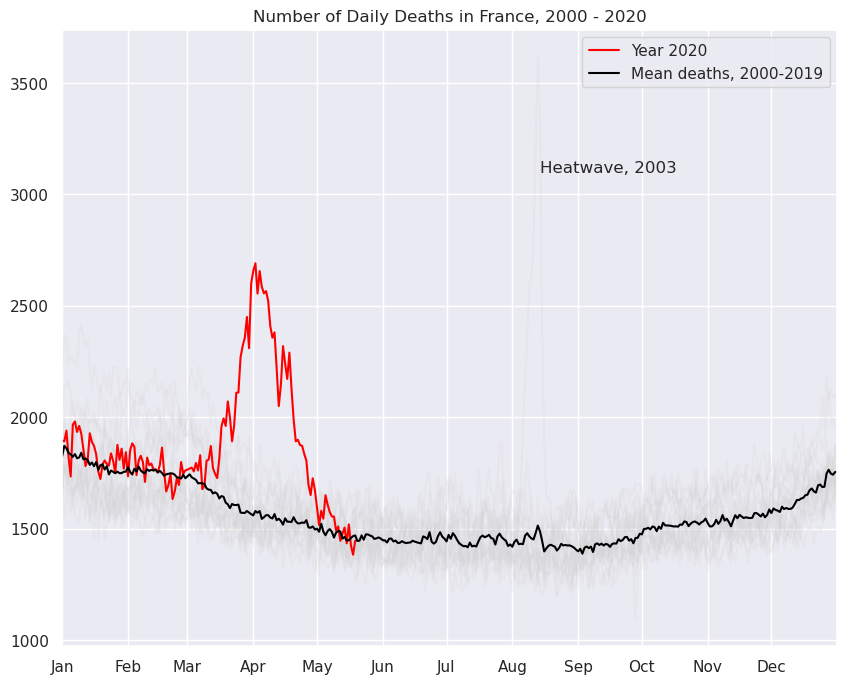

In [25]:
# code your solution 

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim([0, 365])
ax.set_xticks(month_cutoff)
ax.set_xticklabels(month_names)
ax.set_title("Number of Daily Deaths in France, 2000 - 2020")

for year in range(2001, 2020):
    year_text = str(year)
    ax.plot(mort_df.index, mort_df[year_text], color="lightgray", alpha=0.2)

ax.plot(mort_df.index, mort_df["2020"], color="red", label="Year 2020")

available_years = [str(y) for y in range(2000, 2020) if str(y) in mort_df.columns]
mort_df["mean_deaths"] = mort_df[available_years].mean(axis=1)

ax.plot(mort_df.index, mort_df["mean_deaths"], color="black", label="Mean deaths, 2000-2019")
ax.text(225, 3100, "Heatwave, 2003")

ax.legend()
fig

## Ex 6: Presentation

Using data from an earlier part of the course, make a PowerPoint (Keynote, Google Slides, etc.) presentation. Using what you have learned, see if you can improve any visualizations you might want to show, export them to PDF or PNG and embed them in a slide deck.

Think about choice of typeface, layout of slides.

(
If you have nothing, use the Call Money Rate example. These links can provide context:
- https://en.wikipedia.org/wiki/Money_market
- https://www.global-rates.com/en/interest-rates/central-banks/central-bank-switzerland/snb-interest-rate.aspx
)